In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
from sklearn.ensemble import HistGradientBoostingRegressor, StackingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import BaggingRegressor
import time
import logging
from sklearn.linear_model import ElasticNet

In [3]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bias(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) - np.asarray(y_pred)))

In [4]:
%run 05_0.1_visualization_helpers.ipynb  


c:\Users\Rosa Melo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# All of our preprocessing helper functions are in this notebook
%run 05_0_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# lists previously defined in 05_0_preproc_helpers.ipynb
numeric_features = num_feat                      # ['year', 'mileage', ...]
categorical_features = cat_feat                  # ['Brand', 'model', 'transmission', 'fuelType']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

N_SPLITS = 8 # the number of folds for K-Fold cross-validation
RANDOM_STATE = 42 # seed to control randomness

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


modelo normal, features todas, sem fe/fs price normal

In [ ]:
# =========================================================
# K-FOLD CROSS-VALIDATION
# =========================================================

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# =========================================================
# FIXED MODEL CONFIGURATION
# =========================================================

params = {
    "hgb": {
        "max_iter": 600,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": 0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split": 6,
        "min_samples_leaf": 1,
        "max_features": None,
        "max_depth": 15,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 1200,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

# =========================================================
# LOGGING
# =========================================================

log_path = "stacking_complete_results.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =========================================")
    log("# SINGLE CONFIGURATION CROSS-VALIDATION")
    log("# ENSEMBLE: HGB + RF + ET (STACKING)")
    log("# =========================================")
    log(f"Parameters: {params}")
    log("")

    # -----------------------------------------------------
    # METRIC CONTAINERS
    # -----------------------------------------------------

    fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
    fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
    fold_med_ae = []

    # =====================================================
    # K-FOLD LOOP
    # =====================================================

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

        log(f"\n===== FOLD {fold}/{N_SPLITS} =====")

        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        # -------------------------------------------------
        # PREPROCESSING
        # -------------------------------------------------

        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, year_state)
        X_val   = transform_year_with_model_median(X_val, year_state)

        mileage_state = fit_mileage_imputer(X_train, "mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, mileage_state)
        X_val   = transform_mileage_imputer(X_val, mileage_state)

        engine_state = fit_engine_size_imputer(X_train, "engineSize")
        X_train = transform_engine_size_imputer(X_train, engine_state)
        X_val   = transform_engine_size_imputer(X_val, engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, "mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, mpg_state)
        X_val   = transform_mpg_imputer(X_val, mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, owners_state)
        X_val   = transform_previous_owners_imputer(X_val, owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val, _, _   = transform_invalid_models(X_val, model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val, _, _   = transform_transmission_resolver(X_val, transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

        # -------------------------------------------------
        # ENCODING
        # -------------------------------------------------

        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])
        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_final = pd.concat([X_train[numeric_features], X_train_high, X_train_low], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features],   X_val_high,   X_val_low], axis=1)

        # -------------------------------------------------
        # SCALING
        # -------------------------------------------------

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_final)
        X_val_scaled   = scaler.transform(X_val_final)

        # -------------------------------------------------
        # STACKING MODEL
        # -------------------------------------------------

        estimators = [
            ("hgb", HistGradientBoostingRegressor(**params["hgb"])),
            ("rf",  RandomForestRegressor(**params["rf"])),
            ("et",  ExtraTreesRegressor(**params["et"]))
        ]

        meta_model = ElasticNet(
            alpha=np.float64(0.00022539339047347913),
            l1_ratio=np.float64(0.4),
            random_state=RANDOM_STATE
        )

        stack = StackingRegressor(
            estimators=estimators,
            final_estimator=meta_model,
            cv=5,
            n_jobs=1
        )

        stack.fit(X_train_scaled, y_train)

        # -------------------------------------------------
        # PREDICTIONS
        # -------------------------------------------------

        y_tr = stack.predict(X_train_scaled)
        y_val_pred = stack.predict(X_val_scaled)

        # -------------------------------------------------
        # METRICS
        # -------------------------------------------------

        mae_tr  = mean_absolute_error(y_train, y_tr)
        rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr))
        r2_tr   = r2_score(y_train, y_tr)
        bias_tr = np.mean(y_train - y_tr)

        mae_val  = mean_absolute_error(y_val, y_val_pred)
        rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
        r2_val   = r2_score(y_val, y_val_pred)
        bias_val = np.mean(y_val - y_val_pred)
        med_ae   = median_absolute_error(y_val, y_val_pred)

        log(f"[TRAIN] R2={r2_tr:.4f} | RMSE={rmse_tr:.0f} | MAE={mae_tr:.0f} | Bias={bias_tr:.1f}")
        log(f"[VAL]   R2={r2_val:.4f} | RMSE={rmse_val:.0f} | MAE={mae_val:.0f} | Bias={bias_val:.1f}")

        fold_maes_tr.append(mae_tr)
        fold_rmses_tr.append(rmse_tr)
        fold_r2s_tr.append(r2_tr)
        fold_bias_tr.append(bias_tr)

        fold_maes_val.append(mae_val)
        fold_rmses_val.append(rmse_val)
        fold_r2s_val.append(r2_val)
        fold_bias_val.append(bias_val)
        fold_med_ae.append(med_ae)

    # =====================================================
    # FINAL RESULTS
    # =====================================================

    log("\n===== FINAL CROSS-VALIDATION RESULTS =====")
    log(f"[TRAIN AVG] MAE={np.mean(fold_maes_tr):.1f} | R2={np.mean(fold_r2s_tr):.4f} | Bias={np.mean(fold_bias_tr):.1f}")
    log(f"[VAL AVG]   MAE={np.mean(fold_maes_val):.1f} | "
        f"R2={np.mean(fold_r2s_val):.4f} | "
        f"Bias={np.mean(fold_bias_val):.1f} | "
        f"RMSE={np.mean(fold_rmses_val):.1f}")


# =========================================
# SINGLE CONFIGURATION CROSS-VALIDATION
# ENSEMBLE: HGB + RF + ET (STACKING)
# =========================================
Parameters: {'hgb': {'max_iter': 600, 'learning_rate': 0.1, 'max_depth': 20, 'max_leaf_nodes': 127, 'min_samples_leaf': 20, 'l2_regularization': 0, 'random_state': 42}, 'rf': {'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'bootstrap': True, 'random_state': 42, 'n_jobs': -1}, 'et': {'n_estimators': 1200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}}


===== FOLD 1/8 =====
[TRAIN] R2=0.9798 | RMSE=1387 | MAE=890 | Bias=-0.5
[VAL]   R2=0.9583 | RMSE=1942 | MAE=1252 | Bias=-45.5

===== FOLD 2/8 =====
[TRAIN] R2=0.9804 | RMSE=1365 | MAE=901 | Bias=-2.0
[VAL]   R2=0.9541 | RMSE=2074 | MAE=1269 | Bias=-16.7

===== FOLD 3/8 =====
[TRAIN] R2=0.9803 | RMSE=1367 | MAE=888 | Bias=1.

o modelo base mas sem previous owners, log do price

In [ ]:
# =========================================================
# K-FOLD CROSS-VALIDATION
# =========================================================

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

DROP_FROM_MODEL = ["previousOwners"]

#este numeric features ta certo? nao falta year?
numeric_features = ["mileage", "engineSize", "tax", "mpg", "year"]

# =========================================================
# FIXED MODEL CONFIGURATION
# =========================================================

params = {
    "hgb": {
        "max_iter": 1000,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 191,
        "min_samples_leaf": 20,
        "l2_regularization": 3.0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split":2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

# =========================================================
# LOGGING
# =========================================================

log_path = "stacking_no_previous_cv_results.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# ===============================================")
    log("# SINGLE CONFIG CV — WITHOUT previousOwners")
    log("# ENSEMBLE: HGB + RF + ET (STACKING)")
    log("# ===============================================")
    log(f"Parameters: {params}")
    log("")

    # -----------------------------------------------------
    # METRIC CONTAINERS
    # -----------------------------------------------------

    fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
    fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
    fold_med_ae = []

    # =====================================================
    # K-FOLD LOOP
    # =====================================================

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

        log(f"\n===== FOLD {fold}/{N_SPLITS} =====")

        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
        y_train_log = np.log1p(y_train)

        # -------------------------------------------------
        # PREPROCESSING
        # -------------------------------------------------

        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, year_state)
        X_val   = transform_year_with_model_median(X_val, year_state)

        mileage_state = fit_mileage_imputer(X_train, "mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, mileage_state)
        X_val   = transform_mileage_imputer(X_val, mileage_state)

        engine_state = fit_engine_size_imputer(X_train, "engineSize")
        X_train = transform_engine_size_imputer(X_train, engine_state)
        X_val   = transform_engine_size_imputer(X_val, engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, "mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, mpg_state)
        X_val   = transform_mpg_imputer(X_val, mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, owners_state)
        X_val   = transform_previous_owners_imputer(X_val, owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val, _, _   = transform_invalid_models(X_val, model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val, _, _   = transform_transmission_resolver(X_val, transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

        # DROP previousOwners
        X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
        X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

        # -------------------------------------------------
        # ENCODING
        # -------------------------------------------------

        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])
        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_final = pd.concat(
            [X_train[numeric_features], X_train_high, X_train_low], axis=1
        )
        X_val_final = pd.concat(
            [X_val[numeric_features], X_val_high, X_val_low], axis=1
        )

        # -------------------------------------------------
        # SCALING
        # -------------------------------------------------

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_final)
        X_val_scaled   = scaler.transform(X_val_final)

        if fold == 1:
            log(f"  > Features Used ({X_train_final.shape[1]})")

        # -------------------------------------------------
        # MODELS
        # -------------------------------------------------

        estimators = [
            ("hgb", HistGradientBoostingRegressor(**params["hgb"])),
            ("rf",  RandomForestRegressor(**params["rf"])),
            ("et",  ExtraTreesRegressor(**params["et"]))
        ]

        meta_model = ElasticNet(
            alpha=np.float64(0.0017190722018585747),
            l1_ratio=np.float64(0.2),
            random_state=RANDOM_STATE
        )

        stack = StackingRegressor(
            estimators=estimators,
            final_estimator=meta_model,
            cv=5,
            n_jobs=1
        )

        stack.fit(X_train_scaled, y_train_log)

        pred_tr  = np.expm1(stack.predict(X_train_scaled))
        pred_val = np.expm1(stack.predict(X_val_scaled))
        # -------------------------------------------------
        # METRICS
        # -------------------------------------------------

        mae_tr  = mean_absolute_error(y_train, pred_tr)
        rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
        r2_tr   = r2_score(y_train, pred_tr)
        bias_tr = np.mean(y_train - pred_tr)

        mae_val  = mean_absolute_error(y_val, pred_val)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
        r2_val   = r2_score(y_val, pred_val)
        bias_val = np.mean(y_val - pred_val)
        med_ae   = median_absolute_error(y_val, pred_val)

        log(f"[TRAIN] R2={r2_tr:.4f} | RMSE={rmse_tr:.0f} | MAE={mae_tr:.0f} | Bias={bias_tr:.1f}")
        log(f"[VAL]   R2={r2_val:.4f} | RMSE={rmse_val:.0f} | MAE={mae_val:.0f} | Bias={bias_val:.1f}")

        fold_maes_tr.append(mae_tr)
        fold_rmses_tr.append(rmse_tr)
        fold_r2s_tr.append(r2_tr)
        fold_bias_tr.append(bias_tr)

        fold_maes_val.append(mae_val)
        fold_rmses_val.append(rmse_val)
        fold_r2s_val.append(r2_val)
        fold_bias_val.append(bias_val)
        fold_med_ae.append(med_ae)

    # =====================================================
    # FINAL RESULTS
    # =====================================================

    log("\n===== FINAL CROSS-VALIDATION RESULTS =====")
    log(f"[TRAIN AVG] MAE={np.mean(fold_maes_tr):.1f} | "
        f"R2={np.mean(fold_r2s_tr):.4f} | Bias={np.mean(fold_bias_tr):.1f}")
    log(f"[VAL AVG]   MAE={np.mean(fold_maes_val):.1f} | "
        f"R2={np.mean(fold_r2s_val):.4f} | "
        f"Bias={np.mean(fold_bias_val):.1f} | "
        f"RMSE={np.mean(fold_rmses_val):.1f}")


# ===============================================
# SINGLE CONFIG CV — WITHOUT previousOwners
# ENSEMBLE: HGB + RF + ET (STACKING)
# ===============================================
Parameters: {'hgb': {'max_iter': 1000, 'learning_rate': 0.1, 'max_depth': 20, 'max_leaf_nodes': 191, 'min_samples_leaf': 20, 'l2_regularization': 3.0, 'random_state': 42}, 'rf': {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True, 'random_state': 42, 'n_jobs': -1}, 'et': {'n_estimators': 800, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.7, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}}


===== FOLD 1/8 =====
  > Features Used (15)
[TRAIN] R2=0.9751 | RMSE=1540 | MAE=887 | Bias=54.1
[VAL]   R2=0.9604 | RMSE=1894 | MAE=1208 | Bias=39.7

===== FOLD 2/8 =====
[TRAIN] R2=0.9768 | RMSE=1483 | MAE=908 | Bias=55.0
[VAL]   R2=0.9538 | RMSE=2081 | MAE=1242 | Bias=76.6

===== FOLD 3/8 =====
[TRAIN] R2

feature engineering com tudo, sem selection 

fe com fs, 65 percentagem

In [ ]:
# =========================================================
# SINGLE CONFIG — FE + FS + BAGGING
# =========================================================

FS_KEEP_RATIO = 0.65
CONFIG_NAME = "FE_FS65_Stacking"
numeric_features = ["mileage", "engineSize", "tax", "mpg", "year", "previousOwners"]
# ---------------------------------------------------------
# 0) FEATURE SELECTION MODEL (RF)
# ---------------------------------------------------------
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# ---------------------------------------------------------
# 1) MODELS PARAMS — FIXOS
# ---------------------------------------------------------
PARAMS = {
    "hgb": {
        "max_iter": 1000,
        "learning_rate": np.float64(0.12052631578947368),
        "max_depth": 25,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": np.float64(2.394736842105263),
        "max_bins": 255,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split":2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

# ---------------------------------------------------------
# 2) LOGGING
# ---------------------------------------------------------
LOG_FILE = "stacking_fe_fs_65.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w",
    force=True
)
logging.info(f"{CONFIG_NAME} | FS_KEEP_RATIO={FS_KEEP_RATIO} | {N_SPLITS}-fold")

# ---------------------------------------------------------
# 3) K-FOLD
# ---------------------------------------------------------
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

def _normalize_cats(df):
    df = df.copy()
    for col in cols_to_normalize:
        if col in df.columns:
            df[col] = fill_unknown(df[col])
            df = column_string_transformer(df, col, True, "")
    return df

# ---------------------------------------------------------
# 4) EVAL SINGLE CONFIG
# ---------------------------------------------------------
def eval_single_config(name: str, params: dict) -> dict:
    rows = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X), start=1):
        print(f"[{name}] Fold {fold}/{N_SPLITS}")

        X_train = X.iloc[tr_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[tr_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        y_train_log = np.log1p(y_train)

        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        base_cols = [c for c in numeric_features + categorical_features if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # ---------------- CLEANING ----------------
        year_state = fit_year_median(X_train, "year", "model")
        X_train = transform_year_with_model_median(X_train, year_state)
        X_val   = transform_year_with_model_median(X_val,   year_state)

        mileage_state = fit_mileage_imputer(X_train, "mileage", True)
        X_train = transform_mileage_imputer(X_train, mileage_state)
        X_val   = transform_mileage_imputer(X_val,   mileage_state)

        engine_state = fit_engine_size_imputer(X_train, "engineSize")
        X_train = transform_engine_size_imputer(X_train, engine_state)
        X_val   = transform_engine_size_imputer(X_val,   engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, "mpg", True)
        X_train = transform_mpg_imputer(X_train, mpg_state)
        X_val   = transform_mpg_imputer(X_val,   mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   owners_state)

        # ---------------- RESOLVERS ----------------
        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

        # ---------------- FE ----------------
        X_train = add_owners_flagged(X_train, "previousOwners", "owners_flagged", True)
        X_val   = add_owners_flagged(X_val,   "previousOwners", "owners_flagged", True)

        X_train = create_age_and_drop_year(X_train, "year", 2020)
        X_val   = create_age_and_drop_year(X_val,   "year", 2020)

        X_train = add_mileage_features(X_train, "mileage", "age", True, True)
        X_val   = add_mileage_features(X_val,   "mileage", "age", True, True)

        X_train = add_engine_bins(X_train, "engineSize", "engine_bin")
        X_val   = add_engine_bins(X_val,   "engineSize", "engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

        low_card_curr = low_card_features + ["engine_bin"]

        # ---------------- ENCODING ----------------
        te = MyTargetEncoder(5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low], axis=1)

        drop_cols = set(high_card_features + low_card_curr)
        num_cols = [c for c in X_train.columns if c not in drop_cols]

        X_train_final = pd.concat([X_train[num_cols], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[num_cols],   X_val_cat], axis=1)

        scaler = StandardScaler()
        X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
        X_val_final[num_cols]   = scaler.transform(X_val_final[num_cols])

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        # ---------------- FEATURE SELECTION ----------------
        n_feats = X_train_final.shape[1]
        k = max(1, int(np.ceil(FS_KEEP_RATIO * n_feats)))

        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        selector = SelectFromModel(
            rf_fs,
            max_features=k,
            threshold=-np.inf,
            prefit=True
        )

        cols_sel = X_train_final.columns[selector.get_support()]
        X_train_sel = X_train_final[cols_sel]
        X_val_sel   = X_val_final[cols_sel]

        # ---------------- MODELS ----------------
        estimators = [
            ("hgb", HistGradientBoostingRegressor(**params["hgb"])),
            ("rf",  RandomForestRegressor(**params["rf"])),
            ("et",  ExtraTreesRegressor(**params["et"]))
        ]

        meta_model = ElasticNet(
            alpha=np.float64(0.0017190722018585747),
            l1_ratio=np.float64(0.2),
            random_state=RANDOM_STATE
        )

        stack = StackingRegressor(
            estimators=estimators,
            final_estimator=meta_model,
            cv=5,
            n_jobs=1
        )

        stack.fit(X_train_sel, y_train_log)

        pred_tr  = np.expm1(stack.predict(X_train_sel))
        pred_val = np.expm1(stack.predict(X_val_sel))

        rows.append({
            "fold": fold,
            "n_total": n_feats,
            "n_selected": len(cols_sel),
            "rmse_val": rmse(y_val, pred_val),
            "mae_val": mean_absolute_error(y_val, pred_val),
            "r2_val": r2_score(y_val, pred_val),
            "bias_val": bias(y_val, pred_val)
        })

    df = pd.DataFrame(rows)

    return {
        "config": name,
        "val_rmse": df.rmse_val.mean(),
        "val_mae": df.mae_val.mean(),
        "val_r2": df.r2_val.mean(),
        "val_bias": df.bias_val.mean(),
        "avg_selected_features": df.n_selected.mean(),
        "avg_total_features": df.n_total.mean()
    }

# ---------------------------------------------------------
# 5) RUN
# ---------------------------------------------------------
result = eval_single_config(CONFIG_NAME, PARAMS)
display(pd.DataFrame([result]))

print("\nFINAL RESULTS")
for k, v in result.items():
    if k != "config":
        print(f"{k}: {v:.4f}")

print(f"\nLog saved to: {LOG_FILE}")


[FE_FS65_Stacking] Fold 1/8
[FE_FS65_Stacking] Fold 2/8
[FE_FS65_Stacking] Fold 3/8
[FE_FS65_Stacking] Fold 4/8
[FE_FS65_Stacking] Fold 5/8
[FE_FS65_Stacking] Fold 6/8
[FE_FS65_Stacking] Fold 7/8
[FE_FS65_Stacking] Fold 8/8


,config,val_rmse,val_mae,val_r2,val_bias,avg_selected_features,avg_total_features
0,FE_FS65_Stacking,2117.180289,1241.484492,0.952542,94.208941,17.0,25.0



FINAL RESULTS
val_rmse: 2117.1803
val_mae: 1241.4845
val_r2: 0.9525
val_bias: 94.2089
avg_selected_features: 17.0000
avg_total_features: 25.0000

Log saved to: stacking_fe_fs_65.log


sem previous owners, log do price,age - sem feature selection

In [ ]:
# =========================================
# SINGLE CONFIG PIPELINE (LOG TARGET + AGE)
# =========================================
#este numeric features está certo?
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]
DROP_FROM_MODEL = ["previousOwners"]

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# FIXED PARAMETERS (uma configuração fixa)
params = {
    "hgb": {
        "max_iter": 1200,
        "learning_rate": 0.07,
        "max_depth": 20,
        "max_leaf_nodes": 191,
        "min_samples_leaf": 16,
        "l2_regularization": 3.0,
        "loss": "squared_error",
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

search_results = []
best_rmse = np.inf
best_config = None

log_path = "no_fs_age_log.txt"

with open(log_path, "w", encoding="utf-8") as log_file:
    
    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()
    
    log("# =============================")
    log("# START OF SINGLE CONFIG PIPELINE (LOG TARGET + AGE FEATURE)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
    fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
    fold_med_ae = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        y_train_log = np.log1p(y_train)
        log(f"\n[FOLD {fold}] Processing fold...")

        # ---------------- Preprocessing / FE ----------------
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val, _, _   = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val, _, _   = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val, _, _   = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val, _, _   = transform_fueltype_resolver(X_val,   fuel_state)

        # FE: age
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        # drop excluded features
        X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
        X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

        # ---------------- Encoding ----------------
        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])
        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high, X_val_low], axis=1)

        # join numeric + categorical
        X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

        if len(numeric_features) > 0:
            scaler = StandardScaler()
            X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
            X_val_final[numeric_features]   = scaler.transform(X_val_final[numeric_features])

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        if fold == 1:
            feature_names = list(X_train_final.columns)
            log(f"  > Features Used ({len(feature_names)}): {feature_names}")

        # ---------------- Train Models ----------------
        estimators = [
                ("hgb", HistGradientBoostingRegressor(**params["hgb"])),
                ("rf",  RandomForestRegressor(**params["rf"])),
                ("et",  ExtraTreesRegressor(**params["et"]))
            ]

        meta_model = ElasticNet(
            alpha=np.float64(0.0017190722018585747),
            l1_ratio=np.float64(0.2),
            random_state=RANDOM_STATE
        )

        stack = StackingRegressor(
            estimators=estimators,
            final_estimator=meta_model,
            cv=5,
            n_jobs=1
        )

        stack.fit(X_train_final, y_train_log)

        pred_tr  = np.expm1(stack.predict(X_train_final))
        pred_val = np.expm1(stack.predict(X_val_final))

        # Metrics
        mae_tr  = mean_absolute_error(y_train, pred_tr)
        rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
        r2_tr   = r2_score(y_train, pred_tr)
        bias_tr = np.mean(y_train - pred_tr)

        mae_val  = mean_absolute_error(y_val, pred_val)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
        r2_val   = r2_score(y_val, pred_val)
        bias_val = np.mean(y_val - pred_val)

        fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
        fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
        fold_med_ae.append(median_absolute_error(y_val, pred_val))

        log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
        log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

    # ---------------- Summary ----------------
    mean_rmse_val = np.mean(fold_rmses_val)
    mean_mae_val  = np.mean(fold_maes_val)
    mean_r2_val   = np.mean(fold_r2s_val)
    mean_bias_val = np.mean(fold_bias_val)

    mean_mae_tr   = np.mean(fold_maes_tr)
    mean_r2_tr    = np.mean(fold_r2s_tr)
    mean_bias_tr  = np.mean(fold_bias_tr)

    log("\nSUMMARY ACROSS FOLDS:")
    log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
    log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

    search_results.append({
        "config": "single_config_age",
        "val_rmse": mean_rmse_val,
        "val_mae": mean_mae_val,
        "val_r2": mean_r2_val,
        "val_bias": mean_bias_val,
        "train_mae": mean_mae_tr,
        "train_r2": mean_r2_tr,
        "train_bias": mean_bias_tr,
        "val_med_ae": np.mean(fold_med_ae)
    })

    log("# END OF PIPELINE")

results_df = pd.DataFrame(search_results)
display(results_df)


# =============================
# START OF SINGLE CONFIG PIPELINE (LOG TARGET + AGE FEATURE)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: no_fs_age_log.txt
# =============================

[FOLD 1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9750 | RMSE: 1543 | MAE: 892 | Bias: 56.3
  > [VAL]   R2: 0.9601 | RMSE: 1901 | MAE: 1212 | Bias: 44.3

[FOLD 2] Processing fold...
  > [TRAIN] R2: 0.9763 | RMSE: 1500 | MAE: 923 | Bias: 55.3
  > [VAL]   R2: 0.9533 | RMSE: 2094 | MAE: 1246 | Bias: 82.0

[FOLD 3] Processing fold...
  > [TRAIN] R2: 0.9769 | RMSE: 1481 | MAE: 887 | Bias: 53.7
  > [VAL]   R2: 0.9502 | RMSE: 2163 | MAE: 1242 | Bias: 128.7

[FOLD 4] Processing fold...
  > [TRAIN] R2: 0.9788 | RMSE: 1410 | MAE: 903 |

,config,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
0,single_config_age,2098.159082,1225.830306,0.953369,92.070382,901.421753,0.976953,54.369274,774.888285


sem previous owners, log do price,age - com fs -80 %

In [ ]:
# =========================================
# SINGLE CONFIG PIPELINE (LOG TARGET + AGE + FS 90%)
# =========================================
#estas numeric features estão bem?
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]
DROP_FROM_MODEL = ["previousOwners"]
FS_KEEP_RATIO = 0.80

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# RandomForest used only to rank feature importances for SelectFromModel
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# FIXED MODEL PARAMETERS
params = {
    "hgb": {
        "max_iter": 600,
        "learning_rate": 0.1,
        "max_depth": 15,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": 3.0,
        "loss": "squared_error",
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split":2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

search_results = []
best_rmse = np.inf
best_config = None

log_path ="mean_age_fs80_log.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF SINGLE CONFIG PIPELINE (LOG TARGET + AGE + FS 80%)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
    fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
    fold_med_ae = []
    fold_nsel = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        y_train_log = np.log1p(y_train)
        log(f"\n[FOLD {fold}] Processing fold...")

        # ---------------- Preprocessing / FE ----------------
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val, _, _   = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val, _, _   = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val, _, _   = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val, _, _   = transform_fueltype_resolver(X_val,   fuel_state)

        # FE: age
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
        X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

        # ---------------- Encoding ----------------
        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])
        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high, X_val_low], axis=1)

        X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

        if len(numeric_features) > 0:
            scaler = StandardScaler()
            X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
            X_val_final[numeric_features]   = scaler.transform(X_val_final[numeric_features])

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        if fold == 1:
            feature_names = list(X_train_final.columns)
            log(f"  > Features before FS ({len(feature_names)}): {feature_names}")

        # ---------------- Feature Selection ----------------
        n_feats = X_train_final.shape[1]
        k = int(np.ceil(FS_KEEP_RATIO * n_feats))
        k = max(1, min(k, n_feats))

        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        selected_cols = X_train_final.columns[selector.get_support()]
        fold_nsel.append(len(selected_cols))

        X_train_sel = X_train_final[selected_cols]
        X_val_sel   = X_val_final[selected_cols]

        if fold == 1:
            log(f"  > Selected features ({len(selected_cols)}/{n_feats}) with FS_KEEP_RATIO={FS_KEEP_RATIO:.2f}")

        # ---------------- Train Models ----------------
        estimators = [
                ("hgb", HistGradientBoostingRegressor(**params["hgb"])),
                ("rf",  RandomForestRegressor(**params["rf"])),
                ("et",  ExtraTreesRegressor(**params["et"]))
            ]

        meta_model = ElasticNet(
            alpha=np.float64(0.0017190722018585747),
            l1_ratio=np.float64(0.2),
            random_state=RANDOM_STATE
        )

        stack = StackingRegressor(
            estimators=estimators,
            final_estimator=meta_model,
            cv=5,
            n_jobs=1
        )

        stack.fit(X_train_final, y_train_log)

        pred_tr  = np.expm1(stack.predict(X_train_final))
        pred_val = np.expm1(stack.predict(X_val_final))

        # Metrics
        mae_tr  = mean_absolute_error(y_train, pred_tr)
        rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
        r2_tr   = r2_score(y_train, pred_tr)
        bias_tr = np.mean(y_train - pred_tr)

        mae_val  = mean_absolute_error(y_val, pred_val)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
        r2_val   = r2_score(y_val, pred_val)
        bias_val = np.mean(y_val - pred_val)

        fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
        fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
        fold_med_ae.append(median_absolute_error(y_val, pred_val))

        log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
        log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

    # ---------------- Summary ----------------
    mean_rmse_val = np.mean(fold_rmses_val)
    mean_mae_val  = np.mean(fold_maes_val)
    mean_r2_val   = np.mean(fold_r2s_val)
    mean_bias_val = np.mean(fold_bias_val)

    mean_mae_tr   = np.mean(fold_maes_tr)
    mean_r2_tr    = np.mean(fold_r2s_tr)
    mean_bias_tr  = np.mean(fold_bias_tr)
    mean_nsel     = float(np.mean(fold_nsel))

    log("\nSUMMARY ACROSS FOLDS:")
    log(f"  Selected features (avg): {mean_nsel:.0f} / {X_train_final.shape[1]}")
    log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
    log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

    search_results.append({
        "config": "single_config_age_fs90",
        "fs_keep_ratio": FS_KEEP_RATIO,
        "avg_selected_features": mean_nsel,
        "val_rmse": mean_rmse_val,
        "val_mae": mean_mae_val,
        "val_r2": mean_r2_val,
        "val_bias": mean_bias_val,
        "train_mae": mean_mae_tr,
        "train_r2": mean_r2_tr,
        "train_bias": mean_bias_tr,
        "val_med_ae": np.mean(fold_med_ae)
    })

    log("# END OF PIPELINE")

results_df = pd.DataFrame(search_results)
display(results_df)


# =============================
# START OF SINGLE CONFIG PIPELINE (LOG TARGET + AGE + FS 80%)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: mean_age_fs80_log.txt
# =============================

[FOLD 1] Processing fold...
  > Features before FS (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > Selected features (12/15) with FS_KEEP_RATIO=0.80
  > [TRAIN] R2: 0.9721 | RMSE: 1631 | MAE: 954 | Bias: 62.3
  > [VAL]   R2: 0.9590 | RMSE: 1926 | MAE: 1226 | Bias: 49.4

[FOLD 2] Processing fold...
  > [TRAIN] R2: 0.9765 | RMSE: 1493 | MAE: 918 | Bias: 54.3
  > [VAL]   R2: 0.9538 | RMSE: 2083 | MAE: 1242 | Bias: 74.0

[FOLD 3] Processing fold...
  > [TRAIN] R2: 0.9753 | RMSE: 1532 | MAE: 920 | Bias: 57.9
  > [VAL]   R2: 0.9501 | RMSE: 2166 | MAE: 1247 | Bias: 128.6

[FOLD 4] Pro

KeyboardInterrupt: 

submissao sem prev owners e log price 

In [8]:
# ==============================================================================
# STACKING SUBMISSION — LOG PRICE / NO previousOwners (CV-ALIGNED)
# ==============================================================================

print("- STACKING submission (log-price, no previousOwners)")

# ==============================================================================
# CONFIG
# ==============================================================================

DROP_FROM_MODEL = ["previousOwners"]

numeric_features = ["mileage", "engineSize", "tax", "mpg", "year"]

high_card_features = ["Brand", "model"]

# ------------------------------------------------------------------
# STACK PARAMS — iguais aos do CV
# ------------------------------------------------------------------

STACK_PARAMS = {
    "hgb": {
        "max_iter": 1000,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 191,
        "min_samples_leaf": 20,
        "l2_regularization": 3.0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

# ==============================================================================
# 1) LOAD TEST
# ==============================================================================

try:
    test_df_raw = pd.read_csv("test.csv")
except:
    test_df_raw = pd.read_csv("../../project_data/test.csv")

ID_COL = next((c for c in ["id", "carID", "carId", "car_id"] if c in test_df_raw.columns), None)

if ID_COL:
    test_ids = test_df_raw[ID_COL]
    X_test = test_df_raw.drop(columns=[ID_COL])
else:
    test_ids = test_df_raw.index
    X_test = test_df_raw.copy()

# ==============================================================================
# 2) TRAIN DATA
# ==============================================================================

X_full = X.copy()
y_full = y.copy()
y_full_log = np.log1p(y_full)

low_card_features = [c for c in categorical_features if c not in high_card_features]

# ==============================================================================
# 3) STRING NORMALIZATION
# ==============================================================================

for col in ["Brand", "model", "transmission", "fuelType"]:
    if col in X_full:
        X_full[col] = fill_unknown(X_full[col])
        X_full = column_string_transformer(X_full, col)
    if col in X_test:
        X_test[col] = fill_unknown(X_test[col])
        X_test = column_string_transformer(X_test, col)

# ==============================================================================
# 4) FIT TRANSFORMS (FULL TRAIN)
# ==============================================================================

year_state = fit_year_median(X_full, "year", "model")
X_full = transform_year_with_model_median(X_full, year_state)

mileage_state = fit_mileage_imputer(X_full, "mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, mileage_state)

engine_state = fit_engine_size_imputer(X_full, "engineSize")
X_full = transform_engine_size_imputer(X_full, engine_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

mpg_state = fit_mpg_imputer(X_full, "mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, mpg_state)

owners_state = fit_previous_owners_imputer(X_full, "previousOwners", "year", "mileage")
X_full = transform_previous_owners_imputer(X_full, owners_state)

brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# ------------------------------------------------------------------
# DROP previousOwners (EXACTLY LIKE CV)
# ------------------------------------------------------------------

X_full = X_full.drop(columns=DROP_FROM_MODEL, errors="ignore")

# ==============================================================================
# 5) ENCODING
# ==============================================================================

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_low = ohe.transform(X_full[low_card_features])

X_train_final = pd.concat(
    [X_full[numeric_features], X_high, X_low],
    axis=1
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)

# ==============================================================================
# 6) STACKING MODEL (LOG TARGET)
# ==============================================================================

estimators = [
    ("hgb", HistGradientBoostingRegressor(**STACK_PARAMS["hgb"])),
    ("rf",  RandomForestRegressor(**STACK_PARAMS["rf"])),
    ("et",  ExtraTreesRegressor(**STACK_PARAMS["et"]))
]

meta_model = ElasticNet(
    alpha=0.0017190722018585747,
    l1_ratio=0.2,
    random_state=RANDOM_STATE,
    max_iter=10000
)

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    n_jobs=1
)

print("- training stacking (log-price)")
stack.fit(X_train_scaled, y_full_log)

# ==============================================================================
# 7) TRANSFORM TEST
# ==============================================================================

X_test = transform_year_with_model_median(X_test, year_state)
X_test = transform_mileage_imputer(X_test, mileage_state)
X_test = transform_engine_size_imputer(X_test, engine_state)
X_test = transform_tax_custom_rules(X_test, "tax", "year", "fuelType", "engineSize")
X_test = transform_mpg_imputer(X_test, mpg_state)
X_test = transform_previous_owners_imputer(X_test, owners_state)

X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

X_test = X_test.drop(columns=DROP_FROM_MODEL, errors="ignore")

X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])

X_test_final = pd.concat(
    [X_test[numeric_features], X_test_high, X_test_low],
    axis=1
)

X_test_final = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)
X_test_scaled = scaler.transform(X_test_final)

# ==============================================================================
# 8) PREDICT + SUBMIT
# ==============================================================================

pred_log = stack.predict(X_test_scaled)
pred = np.expm1(pred_log)
pred = np.maximum(pred, 0)

submission = pd.DataFrame({
    ID_COL if ID_COL else "id": test_ids,
    "price": pred
})

submission.to_csv("submission_stacking_elastic_log_no_previous.csv", index=False)
print("- submission saved")
print(submission.head())


- STACKING submission (log-price, no previousOwners)
- training stacking (log-price)
- submission saved
    carID         price
0   89856  10479.834321
1  106581  22327.583388
2   80886  13808.921655
3  100174  16924.948811
4   81376  23150.535292


submissao kaggle 

In [ ]:
# ==============================================================================
# STACKING SUBMISSION — ALIGNED WITH CV
# ==============================================================================

print("- STACKING submission (CV-aligned)")

# ==============================================================================
# CONFIG
# ==============================================================================

numeric_features = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners"]

STACK_PARAMS = {
    "hgb": {
        "max_iter": 600,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": 0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split": 6,
        "min_samples_leaf": 1,
        "max_features": None,
        "max_depth": 15,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 1200,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

# ==============================================================================
# 1) LOAD TEST
# ==============================================================================

try:
    test_df_raw = pd.read_csv("test.csv")
except:
    test_df_raw = pd.read_csv("../../project_data/test.csv")

ID_COL = next((c for c in ["id", "carID", "carId", "car_id"] if c in test_df_raw.columns), None)

if ID_COL:
    test_ids = test_df_raw[ID_COL]
    X_test = test_df_raw.drop(columns=[ID_COL])
else:
    test_ids = test_df_raw.index
    X_test = test_df_raw.copy()

# ==============================================================================
# 2) TRAIN DATA (SAME AS CV)
# ==============================================================================

X_full = X.copy()
y_full = y.copy()

high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# ==============================================================================
# 3) STRING NORMALIZATION
# ==============================================================================

for col in ["Brand", "model", "transmission", "fuelType"]:
    if col in X_full:
        X_full[col] = fill_unknown(X_full[col])
        X_full = column_string_transformer(X_full, col)
    if col in X_test:
        X_test[col] = fill_unknown(X_test[col])
        X_test = column_string_transformer(X_test, col)

# ==============================================================================
# 4) FIT TRANSFORMS (FULL TRAIN)
# ==============================================================================

year_state = fit_year_median(X_full, "year", "model")
X_full = transform_year_with_model_median(X_full, year_state)

mileage_state = fit_mileage_imputer(X_full, "mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, mileage_state)

engine_state = fit_engine_size_imputer(X_full, "engineSize")
X_full = transform_engine_size_imputer(X_full, engine_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

mpg_state = fit_mpg_imputer(X_full, "mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, mpg_state)

owners_state = fit_previous_owners_imputer(X_full, "previousOwners", "year", "mileage")
X_full = transform_previous_owners_imputer(X_full, owners_state)

brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# ==============================================================================
# 5) ENCODING
# ==============================================================================

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_low = ohe.transform(X_full[low_card_features])

X_train_final = pd.concat(
    [X_full[numeric_features], X_high, X_low], axis=1
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)

# ==============================================================================
# 6) STACKING MODEL
# ==============================================================================

estimators = [
    ("hgb", HistGradientBoostingRegressor(**STACK_PARAMS["hgb"])),
    ("rf",  RandomForestRegressor(**STACK_PARAMS["rf"])),
    ("et",  ExtraTreesRegressor(**STACK_PARAMS["et"]))
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=4.0),
    cv=5,
    passthrough=False,
    n_jobs=1
)

print("- training stacking")
stack.fit(X_train_scaled, y_full)

# ==============================================================================
# 7) TRANSFORM TEST
# ==============================================================================

X_test = transform_year_with_model_median(X_test, year_state)
X_test = transform_mileage_imputer(X_test, mileage_state)
X_test = transform_engine_size_imputer(X_test, engine_state)
X_test = transform_tax_custom_rules(X_test, "tax", "year", "fuelType", "engineSize")
X_test = transform_mpg_imputer(X_test, mpg_state)
X_test = transform_previous_owners_imputer(X_test, owners_state)

X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])

X_test_final = pd.concat(
    [X_test[numeric_features], X_test_high, X_test_low], axis=1
)

X_test_final = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)
X_test_scaled = scaler.transform(X_test_final)

# ==============================================================================
# 8) PREDICT + SUBMIT
# ==============================================================================

pred = stack.predict(X_test_scaled)
pred = np.maximum(pred, 0)

submission = pd.DataFrame({
    ID_COL if ID_COL else "id": test_ids,
    "price": pred
})

submission.to_csv("submission_stacking_kaggle.csv", index=False)
print("- submission saved")
print(submission.head())


- STACKING submission (CV-aligned)
- training stacking
- submission saved
    carID         price
0   89856   9775.768104
1  106581  22908.712227
2   80886  13854.633839
3  100174  17200.757142
4   81376  23293.278476


submissao final 

In [ ]:
# =========================================================
# FINAL STACKING MODEL TRAINING USING FULL DATA
# =========================================================
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
print("FINAL STACKING MODEL: HGB + RF + ET + RIDGE")

params = {
    "hgb": {
        "max_iter": 600,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": 0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split": 6,
        "min_samples_leaf": 1,
        "max_features": None,
        "max_depth": 15,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 1200,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

# -------------------------------
# FULL DATA
# -------------------------------
X_full = X.copy()
y_full = y.copy()

# ============================================================
# PREPROCESSING (FIT ON FULL DATA)
# ============================================================

year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, year_state)

mileage_state = fit_mileage_imputer(X_full, "mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, mileage_state)

engine_state = fit_engine_size_imputer(X_full, "engineSize")
X_full = transform_engine_size_imputer(X_full, engine_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

mpg_state = fit_mpg_imputer(X_full, "mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, mpg_state)

owners_state = fit_previous_owners_imputer(X_full, "previousOwners", "year", "mileage")
X_full = transform_previous_owners_imputer(X_full, owners_state)

brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# ============================================================
# FEATURE ENCODING
# ============================================================

high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

X_full_final = pd.concat([X_full[numeric_features], X_full_cat], axis=1)

print(f"Total features used: {X_full_final.shape[1]}")

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full_final)

X_full_final = pd.DataFrame(X_full_scaled, columns=X_full_final.columns, index=X_full_final.index)

# ============================================================
# STACKING MODEL DEFINITION (FIXED CONFIG)
# ============================================================

estimators = [
    ("hgb", HistGradientBoostingRegressor(**params["hgb"])),
    ("rf",  RandomForestRegressor(**params["rf"])),
    ("et",  ExtraTreesRegressor(**params["et"]))
]

meta = Ridge(alpha=4.0)

stack_final = StackingRegressor(
    estimators=estimators,
    final_estimator=meta,
    cv=5,
    passthrough=False,
    n_jobs=1
)

# ============================================================
# TRAIN FINAL STACKING MODEL
# ============================================================

stack_final.fit(X_full_final, y_full)
print("Final Stacking model trained")

# ============================================================
# FINAL METRICS (FULL DATA — DIAGNOSTIC ONLY)
# ============================================================

y_pred_full = stack_final.predict(X_full_final)

rmse_full = np.sqrt(mean_squared_error(y_full, y_pred_full))
mae_full  = mean_absolute_error(y_full, y_pred_full)
r2_full   = r2_score(y_full, y_pred_full)
bias_full = np.mean(y_full - y_pred_full)

print("\nFINAL MODEL METRICS (FULL DATA)")
print(f"RMSE : {rmse_full:.1f}")
print(f"MAE  : {mae_full:.1f}")
print(f"R2   : {r2_full:.4f}")
print(f"Bias : {bias_full:.1f}")

# ============================================================
# SUBMISSION
# ============================================================

print("\nGenerating submission...")

try:
    test_df_raw = pd.read_csv("test.csv")
except:
    test_df_raw = pd.read_csv("../../project_data/test.csv")

ID_CANDIDATES = ["id", "carID", "carId", "car_id"]
ID_COL = next((c for c in ID_CANDIDATES if c in test_df_raw.columns), None)

if ID_COL:
    test_ids = test_df_raw[ID_COL].copy()
    X_test = test_df_raw.drop(columns=[ID_COL]).copy()
else:
    test_ids = test_df_raw.index.copy()
    X_test = test_df_raw.copy()

# --- TRANSFORM ONLY ---
X_test = transform_year_with_model_median(X_test, year_state)
X_test = transform_mileage_imputer(X_test, mileage_state)
X_test = transform_engine_size_imputer(X_test, engine_state)
X_test = transform_tax_custom_rules(X_test, "tax", "year", "fuelType", "engineSize")
X_test = transform_mpg_imputer(X_test, mpg_state)
X_test = transform_previous_owners_imputer(X_test, owners_state)

X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# --- ENCODING ---
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])

X_test_cat = pd.concat([X_test_high, X_test_low], axis=1)

X_test_final = pd.concat([X_test[numeric_features], X_test_cat], axis=1)

# --- SCALING ---
X_test_scaled = scaler.transform(X_test_final)

# --- PREDICT ---
test_preds = stack_final.predict(X_test_scaled)

submission = pd.DataFrame({
    ID_COL if ID_COL else "id": test_ids,
    "price": test_preds
})

submission_filename = "submission_stacking_kaggle.csv"
submission.to_csv(submission_filename, index=False)

print(f"✔ Submission saved: {submission_filename}")
print(submission.head())


FINAL STACKING MODEL: HGB + RF + ET + RIDGE
Total features used: 16
Final Stacking model trained

FINAL MODEL METRICS (FULL DATA)
RMSE : 1365.4
MAE  : 902.4
R2   : 0.9803
Bias : -3.6

Generating submission...


c:\Users\Rosa Melo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rosa Melo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rosa Melo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(


✔ Submission saved: submission_stacking_final.csv
    carID         price
0   89856   9775.768104
1  106581  20283.240458
2   80886  13378.556593
3  100174  16519.394134
4   81376  21717.814932



Generating diagnostic plots...


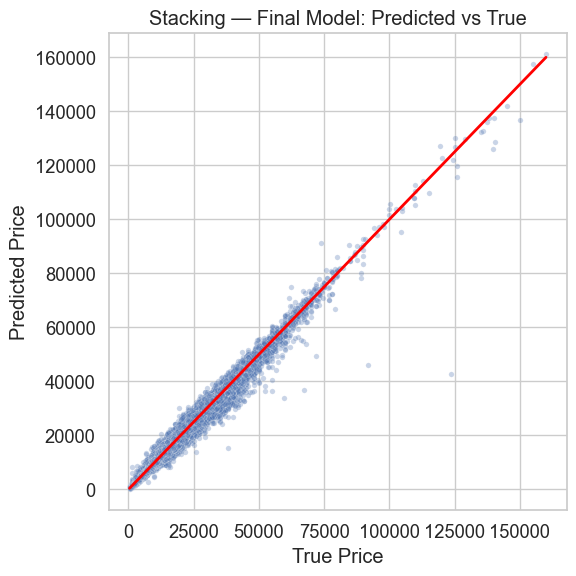

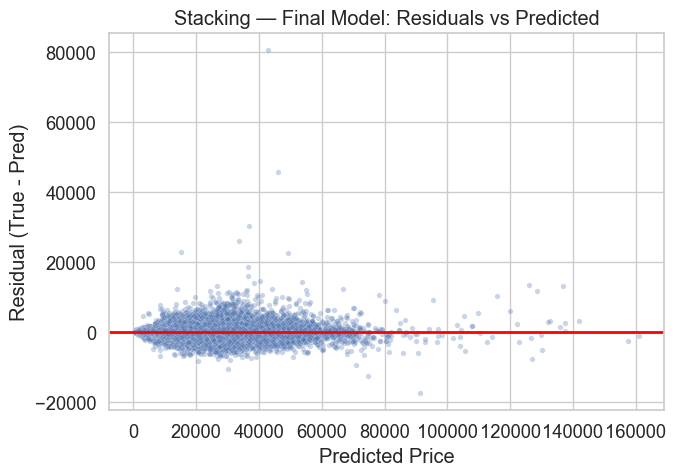

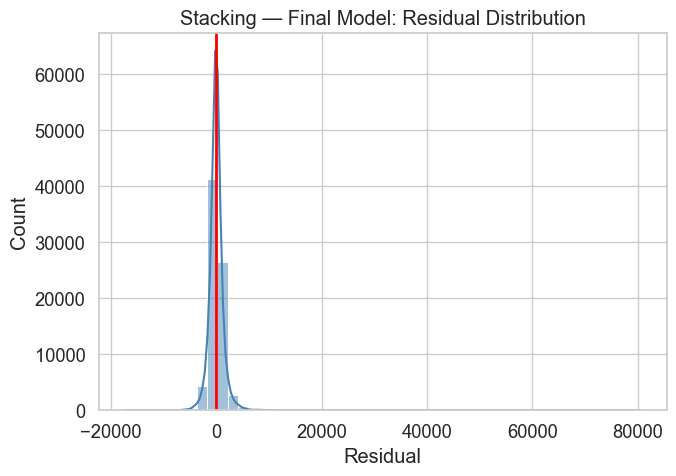

c:\Users\Rosa Melo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


PicklingError: Could not pickle the task to send it to the workers.

In [ ]:
print("\nGenerating diagnostic plots...")

plot_pred_vs_true(stack_final, model_name="Stacking — Final Model")
plot_residuals(stack_final, model_name="Stacking — Final Model")

# Residual distribution
plot_residual_distribution(stack_final, model_name="Stacking — Final Model")



print("All plots generated")

visualizações 